# Summarization (PyTorch)

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate
# To run the training on TPU, you will need to uncomment the following line:
# !pip install cloud-tpu-client==0.10 torch==1.9.0 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.9-cp37-cp37m-linux_x86_64.whl
!apt install git-lfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 3,908 kB of archives.
After this operation, 11.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 git-lfs amd64 3.4.1-1ubuntu0.4 [3,908 kB]
Fetched 3,908 kB in 1s (3,598 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.4.1-1ubuntu0.4_amd64.deb ...
Unpacking git-lfs (3.4.1-1ubuntu0.4) ...
Setting up git-lfs (3.4.1-1ubuntu0.4) ...
Processing triggers for man-db (2.12.0-4build2) ...


You will need to setup git, adapt your email and name in the following cell.

In [1]:
!git config --global user.email "thanapol.sjr@gmail.com"
!git config --global user.name "thanapol"

You will also need to be logged in to the Hugging Face Hub. Execute the following and enter your credentials.

In [3]:
from huggingface_hub import notebook_login

notebook_login()

In [5]:
from datasets import load_dataset

def load_amazon_reviews(lang):
    base = f"hf://datasets/mteb/amazon_reviews_multi@refs%2Fconvert%2Fparquet/{lang}"
    ds = load_dataset("parquet", data_files={
        "train": f"{base}/train/0000.parquet",
        "validation": f"{base}/validation/0000.parquet",
        "test": f"{base}/test/0000.parquet",
    })

    def split_title_body(example):
        title, _, body = example["text"].partition("\n\n")
        return {"review_title": title, "review_body": body}

    ds = ds.map(split_title_body, remove_columns=["text", "label_text"])
    return ds.rename_column("label", "stars")

spanish_dataset = load_amazon_reviews("es")
english_dataset = load_amazon_reviews("en")
english_dataset

es/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 24.6MB            

es/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/613k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/619k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'stars', 'review_title', 'review_body'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'stars', 'review_title', 'review_body'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'stars', 'review_title', 'review_body'],
        num_rows: 5000
    })
})

In [6]:
def show_samples(dataset, num_samples=3, seed=42):
    sample = dataset["train"].shuffle(seed=seed).select(range(num_samples))
    for example in sample:
        print(f"\n'>> Title: {example['review_title']}'")
        print(f"'>> Review: {example['review_body']}'")


show_samples(english_dataset)


'>> Title: Worked in front position, not rear'
'>> Review: 3 stars because these are not rear brakes as stated in the item description. At least the mount adapter only worked on the front fork of the bike that I got it for.'

'>> Title: meh'
'>> Review: Does it’s job and it’s gorgeous but mine is falling apart, I had to basically put it together again with hot glue'

'>> Title: Can't beat these for the money'
'>> Review: Bought this for handling miscellaneous aircraft parts and hanger "stuff" that I needed to organize; it really fit the bill. The unit arrived quickly, was well packaged and arrived intact (always a good sign). There are five wall mounts-- three on the top and two on the bottom. I wanted to mount it on the wall, so all I had to do was to remove the top two layers of plastic drawers, as well as the bottom corner drawers, place it when I wanted and mark it; I then used some of the new plastic screw in wall anchors (the 50 pound variety) and it easily mounted to the wall. 

In [14]:
from datasets import concatenate_datasets, DatasetDict

books_dataset = DatasetDict()
for split in english_dataset.keys():
    books_dataset[split] = concatenate_datasets(
        [english_dataset[split], spanish_dataset[split]]
    ).shuffle(seed=42)
books_dataset["train"] = books_dataset["train"].select(range(20000))

show_samples(books_dataset)


'>> Title: NOT TO OUR LIKING'
'>> Review: They are to small and to thin; not what we buy at COSTCO; maybe purchased wrong ones??'

'>> Title: NO GRABA NI HACE FOTOS SIN WIFI'
'>> Review: EN REALIDAD LA CAMARA VA BIEN,, PERO SIN WIFI NO FUNCIONA, NI HACE FOTOS NI GRABA AUNQUE TENGA LA TARGETA DENTRO,, POR LO DEMAS ESTA BIEN,,'

'>> Title: espejo'
'>> Review: esta muy bien, lo único la luz... que sino te acercas bastante no hace mucho. Ilumina muy bien si estas muy cerca, la cara del espejo.'


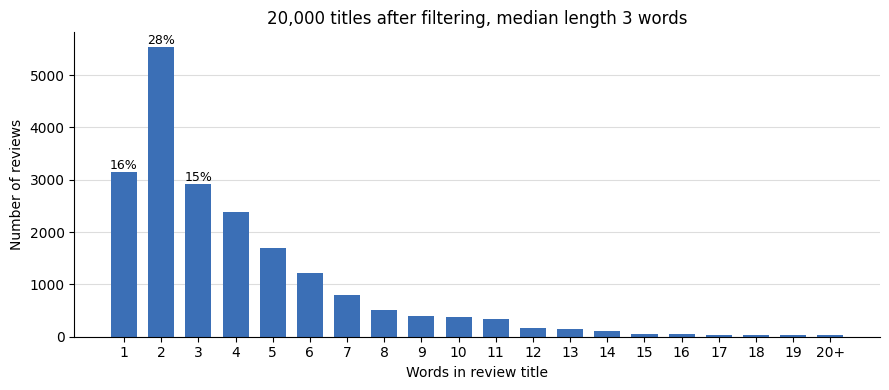

In [15]:
from collections import Counter
import matplotlib.pyplot as plt


def plot_title_lengths(dataset, max_words=20, label_first=3):
    """Bar chart of how many words each review title has."""
    lengths = [len(t.split()) for t in dataset["review_title"]]
    total = len(lengths)
    counts = Counter(min(n, max_words) for n in lengths)
    x = list(range(min(lengths), max_words + 1))
    y = [counts.get(n, 0) for n in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x, y, width=0.7, color="#3B6FB6")
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) if n < max_words else f"{max_words}+" for n in x])
    ax.set_xlabel("Words in review title")
    ax.set_ylabel("Number of reviews")
    median = sorted(lengths)[total // 2]
    ax.set_title(f"{total:,} titles after filtering, median length {median} words")
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.8)
    ax.set_axisbelow(True)
    for i in range(min(label_first, len(x))):
        ax.text(x[i], y[i], f"{100 * y[i] / total:.0f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_title_lengths(books_dataset["train"])

In [16]:
books_dataset = books_dataset.filter(lambda x: len(x["review_title"].split()) > 2)

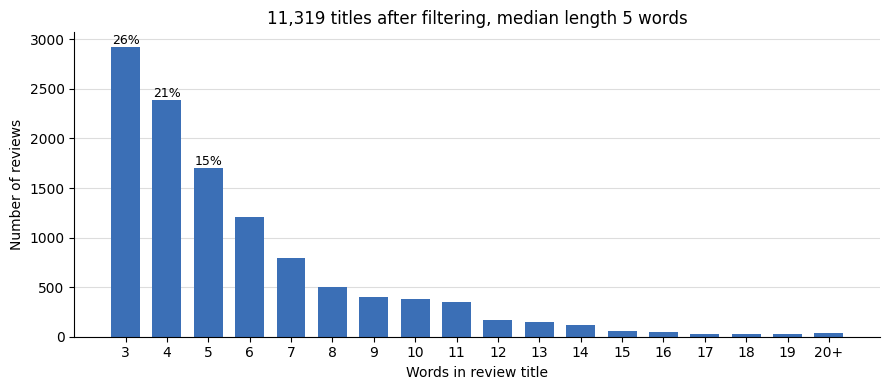

In [17]:
books_dataset = books_dataset.filter(lambda x: len(x["review_title"].split()) > 2)
plot_title_lengths(books_dataset["train"])

In [9]:
from transformers import AutoTokenizer

model_checkpoint = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [18]:
inputs = tokenizer("I loved reading the Hunger Games!")
inputs

{'input_ids': [336, 259, 28387, 11807, 287, 62893, 295, 12507, 309, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [19]:
tokenizer.convert_ids_to_tokens(inputs.input_ids)

['▁I', '▁', 'loved', '▁reading', '▁the', '▁Hung', 'er', '▁Games', '!', '</s>']

In [20]:
max_input_length = 512
max_target_length = 30


def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["review_body"],
        max_length=max_input_length,
        truncation=True,
    )
    labels = tokenizer(
        examples["review_title"], max_length=max_target_length, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [21]:
tokenized_datasets = books_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/11319 [00:00<?, ? examples/s]

Map:   0%|          | 0/5765 [00:00<?, ? examples/s]

Map:   0%|          | 0/5714 [00:00<?, ? examples/s]

In [22]:
generated_summary = "I absolutely loved reading the Hunger Games"
reference_summary = "I loved reading the Hunger Games"

In [25]:
!pip install -q evaluate rouge_score nltk
!pip install -q evaluate rouge_score nltk sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [26]:
import evaluate

rouge_score = evaluate.load("rouge")

In [27]:
scores = rouge_score.compute(
    predictions=[generated_summary], references=[reference_summary]
)
scores

{'rouge1': np.float64(0.923076923076923),
 'rouge2': np.float64(0.7272727272727272),
 'rougeL': np.float64(0.923076923076923),
 'rougeLsum': np.float64(0.923076923076923)}

In [29]:
scores["rouge1"]

np.float64(0.923076923076923)

In [30]:
!pip install nltk

In [31]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [33]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
def evaluate_baseline(dataset, metric):
    summaries = [three_sentence_summary(text) for text in dataset["review_body"]]
    return metric.compute(predictions=summaries, references=dataset["review_title"])

In [36]:
import pandas as pd

score = evaluate_baseline(books_dataset["validation"], rouge_score)
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
rouge_dict = dict((rn, round(score[rn] * 100, 2)) for rn in rouge_names)
rouge_dict

{'rouge1': np.float64(18.65),
 'rouge2': np.float64(10.39),
 'rougeL': np.float64(17.37),
 'rougeLsum': np.float64(17.8)}

In [37]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.20GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [38]:
from huggingface_hub import notebook_login

notebook_login()

In [40]:
from transformers import Seq2SeqTrainingArguments

batch_size = 8
num_train_epochs = 8
# Show the training loss with every epoch
logging_steps = len(tokenized_datasets["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

args = Seq2SeqTrainingArguments(
    output_dir=f"{model_name}-finetuned-amazon-en-es",
    eval_strategy="epoch",
    learning_rate=5.6e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    logging_steps=logging_steps,
    push_to_hub=True,
)

In [47]:
import numpy as np


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Decode generated summaries into text
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    # Replace -100 in the labels as we can't decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    # Decode reference summaries into text
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    # ROUGE expects a newline after each sentence
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]
    # Compute ROUGE scores
    result = rouge_score.compute(
        predictions=decoded_preds, references=decoded_labels, use_stemmer=True
    )
    # Extract the median scores
    result = {key: value * 100 for key, value in result.items()}
    return {k: round(v, 4) for k, v in result.items()}

In [48]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [49]:
tokenized_datasets = tokenized_datasets.remove_columns(
    books_dataset["train"].column_names
)

ValueError: Column name ['stars', 'review_title', 'id', 'review_body'] not in the dataset. Current columns in the dataset: ['input_ids', 'attention_mask', 'labels']

In [50]:
features = [tokenized_datasets["train"][i] for i in range(2)]
data_collator(features)

{'input_ids': tensor([[ 22947,    335,    259,  59445,    435,    335,  16432,    259,    276,
            319,  28373,  40086,    537,    261,   3861,    259,  24043,  17560,
            259,    276,    362,  20307,    870,    426,   7241,    319,  28373,
          20156,    268,    260,   2862,  90902,   6323,   1349,  41364,   1523,
              1],
        [  8739,   6396,    305,    287,   5689,  19514,    527, 177334,    345,
            260,    259,  27531,   8778,    288,  16857,    305,    336,    259,
           3659,    287,  10988,    259,   2364,  14007,    484,    260,    564,
          35514,  22677,      1,      0,      0,      0,      0,      0,      0,
              0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]]), 'labels': tensor([[4

In [51]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [52]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,3.424243,3.061397,18.724200,9.348400,18.151600,18.192700
2,3.411935,2.888608,19.046700,9.865700,18.457500,18.473900
3,3.217048,2.849670,19.417200,10.333000,18.826700,18.852700
4,3.104362,2.832635,19.734100,10.554800,19.142800,19.199400
5,3.023390,2.823438,20.265500,10.867100,19.599200,19.628100
6,2.965618,2.819744,20.140300,10.764700,19.508800,19.548900
7,2.927763,2.804974,19.874900,10.610500,19.255500,19.276600
8,2.902271,2.803346,20.029900,10.747200,19.402500,19.448300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11320, training_loss=3.121918120738053, metrics={'train_runtime': 1162.1761, 'train_samples_per_second': 77.916, 'train_steps_per_second': 9.74, 'total_flos': 1.299697824881664e+16, 'train_loss': 3.121918120738053, 'epoch': 8.0})

In [53]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum
2.902271,2.803346,8,20.029900,10.747200,19.402500,19.448300


{'eval_loss': 2.8033463954925537,
 'eval_rouge1': 20.0299,
 'eval_rouge2': 10.7472,
 'eval_rougeL': 19.4025,
 'eval_rougeLsum': 19.4483}

In [54]:
tokenized_datasets.set_format("torch")

In [55]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [56]:
from torch.utils.data import DataLoader

batch_size = 8
train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    collate_fn=data_collator,
    batch_size=batch_size,
)
eval_dataloader = DataLoader(
    tokenized_datasets["validation"], collate_fn=data_collator, batch_size=batch_size
)

In [57]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [58]:
from accelerate import Accelerator

accelerator = Accelerator()
model, optimizer, train_dataloader, eval_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader
)

In [59]:
from transformers import get_scheduler

num_train_epochs = 10
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_train_epochs * num_update_steps_per_epoch

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

In [60]:
def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [label.strip() for label in labels]

    # ROUGE expects a newline after each sentence
    preds = ["\n".join(nltk.sent_tokenize(pred)) for pred in preds]
    labels = ["\n".join(nltk.sent_tokenize(label)) for label in labels]

    return preds, labels

In [61]:
from huggingface_hub import get_full_repo_name

model_name = "test-bert-finetuned-squad-accelerate"
repo_name = get_full_repo_name(model_name)
repo_name

'thanapolsjr/test-bert-finetuned-squad-accelerate'

In [63]:
from huggingface_hub import HfApi

api = HfApi()
output_dir = "results-mt5-finetuned-squad-accelerate"
api.create_repo(repo_name, exist_ok=True)

RepoUrl('https://huggingface.co/thanapolsjr/test-bert-finetuned-squad-accelerate', endpoint='https://huggingface.co', repo_type='model', repo_id='thanapolsjr/test-bert-finetuned-squad-accelerate')

In [ ]:
from tqdm.auto import tqdm
import torch
import numpy as np

progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_train_epochs):
    # Training
    model.train()
    for step, batch in enumerate(train_dataloader):
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

    # Evaluation
    model.eval()
    for step, batch in enumerate(eval_dataloader):
        with torch.no_grad():
            generated_tokens = accelerator.unwrap_model(model).generate(
                batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

            generated_tokens = accelerator.pad_across_processes(
                generated_tokens, dim=1, pad_index=tokenizer.pad_token_id
            )
            labels = batch["labels"]

            # If we did not pad to max length, we need to pad the labels too
            labels = accelerator.pad_across_processes(
                batch["labels"], dim=1, pad_index=tokenizer.pad_token_id
            )

            generated_tokens = accelerator.gather(generated_tokens).cpu().numpy()
            labels = accelerator.gather(labels).cpu().numpy()

            # Replace -100 in the labels as we can't decode them
            labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
            if isinstance(generated_tokens, tuple):
                generated_tokens = generated_tokens[0]
            decoded_preds = tokenizer.batch_decode(
                generated_tokens, skip_special_tokens=True
            )
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

            decoded_preds, decoded_labels = postprocess_text(
                decoded_preds, decoded_labels
            )

            rouge_score.add_batch(predictions=decoded_preds, references=decoded_labels)

    # Compute metrics
    result = rouge_score.compute()
    # Extract the median ROUGE scores
    result = {key: value * 100 for key, value in result.items()}
    result = {k: round(v, 4) for k, v in result.items()}
    print(f"Epoch {epoch}:", result)

    # Save and upload
    accelerator.wait_for_everyone()
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.save_pretrained(output_dir, save_function=accelerator.save)
    if accelerator.is_main_process:
        tokenizer.save_pretrained(output_dir)
        api.upload_folder(
            folder_path=output_dir,
            repo_id=repo_name,
            commit_message=f"Training in progress epoch {epoch}",
            run_as_future=True,
        )

  0%|          | 0/14150 [00:00<?, ?it/s]

Epoch 0: {'rouge1': np.float64(5.0779), 'rouge2': np.float64(1.2502), 'rougeL': np.float64(4.9541), 'rougeLsum': np.float64(4.9512)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1: {'rouge1': np.float64(9.5399), 'rouge2': np.float64(2.5402), 'rougeL': np.float64(9.3489), 'rougeLsum': np.float64(9.3446)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import pipeline

hub_model_id = "huggingface-course/mt5-small-finetuned-amazon-en-es"
summarizer = pipeline("summarization", model=hub_model_id)

In [ ]:
def print_summary(idx):
    review = books_dataset["test"][idx]["review_body"]
    title = books_dataset["test"][idx]["review_title"]
    summary = summarizer(books_dataset["test"][idx]["review_body"])[0]["summary_text"]
    print(f"'>>> Review: {review}'")
    print(f"\n'>>> Title: {title}'")
    print(f"\n'>>> Summary: {summary}'")

In [ ]:
print_summary(100)

'>>> Review: Nothing special at all about this product... the book is too small and stiff and hard to write in. The huge sticker on the back doesn’t come off and looks super tacky. I would not purchase this again. I could have just bought a journal from the dollar store and it would be basically the same thing. It’s also really expensive for what it is.'

'>>> Title: Not impressed at all... buy something else'

'>>> Summary: Nothing special at all about this product'

In [ ]:
print_summary(0)

'>>> Review: Es una trilogia que se hace muy facil de leer. Me ha gustado, no me esperaba el final para nada'

'>>> Title: Buena literatura para adolescentes'

'>>> Summary: Muy facil de leer'